# Endometriosis Risk Model — chi teng's part

**Bio-Hackathon 2026 (NTU)** · 

This notebook builds the Endometriosis side of our team's risk-score pipeline.
The PCOS side is being worked on separately by a teammate; this notebook is
designed so both halves can plug into the same downstream layers.

## Our project idea (recap)

There are **two patient types** on the patient-facing side:

1. **Type 1 — Comes to the clinic with existing/recent symptoms.**
   We use a *clinical-feature* risk model to produce a risk score that helps
   the doctor make a decision faster.
2. **Type 2 — Has never been screened.**
   We push them a short consent-based symptom form. We compute an early-warning
   risk score. If they look high-risk, we tell them to see a doctor — then the
   Type-1 model takes over at the clinic.

Both flows use the **same** trained endometriosis risk model — the difference
is just the UI surface (doctor-side dashboard vs. patient-facing form result)
and the threshold the team picks for "high risk" in each context.

On the **doctor side**, the score is decision-aid only — not a replacement
for clinical judgment.

## Datasets used in this notebook

| Dataset | File | Role here |
|---|---|---|
| Endometriosis common features (Kaggle, **synthetic, n=10,000**) | `(Supplementary_Dataset)_structured_endometriosis_data.csv` | Train + evaluate the Endo risk model |
| Endometrium single-cell scRNA-seq (Nature 2024 paper, 10x outputs) | `Mc##-C/F.tar` files (10x feature barcode matrices) | **EDA only** — sanity-check & summary, not part of the risk model |

> ⚠️ The structured Endo dataset is **synthetic** (Kaggle-style realistic data).
> The model patterns are learnable, but real-world accuracy will need validation
> on actual patient data before clinical use. We flag this clearly throughout.

## What this notebook covers
1. Data cleaning
2. Feature engineering
3. Exploratory data analysis
4. Unified feature schema (cross-compatible with PCOS dataset)
5. Train/test split
6. Model training (Random Forest + XGBoost)
7. Probability prediction
8. Evaluation (ROC-AUC, precision, recall, F1, confusion matrix)
9. Explainability (SHAP)
10. Risk stratification (Low / Moderate / High / Very High)
11. Single-cell dataset EDA (brief)
12. Summary of changes made

PCOS is being handled in a separate teammate notebook. This notebook focuses
entirely on the **endometriosis** side. The shared feature schema in Section 5
keeps both notebooks aligned on column names and encodings.

## 1. Setup and data load

Standard imports. If something is missing, install with
`!pip install scikit-learn xgboost shap matplotlib seaborn`.

In [22]:
!pip install scikit-learn xgboost shap matplotlib seaborn

In [23]:
# Core
import os, json, gzip, tarfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve,
)
import xgboost as xgb
import shap

# Single-cell (optional EDA)
from scipy.io import mmread

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RNG = 42  # reproducibility — keep this fixed everywhere
print("Environment ready.")

Environment ready.


In [24]:
# --- File paths ---

DATA_DIR = Path(".")
if not (DATA_DIR / "(Supplementary_Dataset)_structured_endometriosis_data.csv").exists():
    # Fallback to common alt path used during dev
    alt = Path("..")
    if (alt / "(Supplementary_Dataset)_structured_endometriosis_data.csv").exists():
        DATA_DIR = alt

ENDO_CSV = DATA_DIR / "(Supplementary_Dataset)_structured_endometriosis_data.csv"
print("Endo CSV path:", ENDO_CSV.resolve())

# Load raw
endo_raw = pd.read_csv(ENDO_CSV)
print("Loaded:", endo_raw.shape)
endo_raw.head()

Endo CSV path: C:\Users\jungs\sbs\(Supplementary_Dataset)_structured_endometriosis_data.csv
Loaded: (10000, 7)


,Age,Menstrual_Irregularity,Chronic_Pain_Level,Hormone_Level_Abnormality,Infertility,BMI,Diagnosis
0,24,1,8.361531,0,0,19.451314,0
1,37,1,4.995508,0,0,22.388436,0
2,46,1,3.363996,1,0,21.320443,0
3,32,1,5.246037,0,0,20.177715,1
4,28,1,3.898932,1,0,23.538103,1


## 2. Data cleaning

For this synthetic dataset, cleaning is mostly verification — we still run the
checks because **this exact code will need to handle real patient data** when
the website forwards form responses later.

In [25]:
def clean_endo(df: pd.DataFrame) -> pd.DataFrame:
    '''Clean the endometriosis symptoms dataset.

    Steps:
      1. Drop exact-duplicate rows (would bias the model).
      2. Drop rows with missing target (Diagnosis) — can't learn from those.
      3. Impute remaining missing values:
         - binary symptom columns -> 0 (assume "not reported" = absent)
         - continuous columns (Age, BMI, Chronic_Pain_Level) -> median
      4. Clip implausible values (BMI < 12 or > 60, Age < 12 or > 80).
    '''
    df = df.copy()
    before = len(df)

    df = df.drop_duplicates()
    df = df.dropna(subset=["Diagnosis"])

    binary_cols = ["Menstrual_Irregularity", "Hormone_Level_Abnormality", "Infertility"]
    for c in binary_cols:
        df[c] = df[c].fillna(0).astype(int)

    for c in ["Age", "BMI", "Chronic_Pain_Level"]:
        df[c] = df[c].fillna(df[c].median())

    # Sanity clip
    df["BMI"] = df["BMI"].clip(lower=12, upper=60)
    df["Age"] = df["Age"].clip(lower=12, upper=80)
    df["Chronic_Pain_Level"] = df["Chronic_Pain_Level"].clip(lower=0, upper=10)

    df["Diagnosis"] = df["Diagnosis"].astype(int)

    print(f"Cleaning: {before} -> {len(df)} rows ({before - len(df)} dropped)")
    return df.reset_index(drop=True)

endo = clean_endo(endo_raw)
print("\nMissing after cleaning:")
print(endo.isna().sum())
print("\nDuplicates after cleaning:", endo.duplicated().sum())

Cleaning: 10000 -> 10000 rows (0 dropped)

Missing after cleaning:
Age                          0
Menstrual_Irregularity       0
Chronic_Pain_Level           0
Hormone_Level_Abnormality    0
Infertility                  0
BMI                          0
Diagnosis                    0
dtype: int64

Duplicates after cleaning: 0


## 3. Feature engineering

The dataset already arrives mostly numeric, so this section is light:

- **Cycle regularity** — the raw Endo CSV has `Menstrual_Irregularity` where
  `1 = irregular`. The team's agreed convention is the **opposite**: `1 = Regular,
  0 = Irregular`. We flip it and rename the column to `Cycle_Regular` to match
  what we're using on the PCOS side.
- **Other binary symptoms** (`Hormone_Level_Abnormality`, `Infertility`) are
  already 0/1 with 1 = symptom present — no transformation needed.
- **Chronic_Pain_Level** is a 0–10 continuous severity score. We keep the
  continuous form for the tree models, **and** we add a discrete bucket
  (`Pain_Severity_Cat`: 0=none, 1=mild, 2=moderate, 3=severe) so the
  unified-schema layer can talk to symptom forms that only collect
  mild/moderate/severe (no 0–10 slider needed on the consent form).
- **BMI** → WHO category buckets (underweight / normal / overweight / obese).
- **Age** → reproductive-life-stage buckets to mirror how clinicians actually
  think about endometriosis risk by life stage.

### A note for the PCOS teammate
The PCOS dataset has a `Cycle(R/I)` column coded as `2 = Regular, 4 = Irregular`.
Those numbers are just labels — remap them to our **team-agreed convention**:
**`1 = Regular, 0 = Irregular`**. One-liner for the PCOS side:

```python
df["Cycle_Regular"] = (df["Cycle(R/I)"] == 2).astype(int)
```

In our unified schema below, the column is called `Cycle_Regular` and the
encoding is the same across both datasets so the PCOS teammate's notebook
and this one stay aligned on what every column means.

In [26]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Flip Menstrual_Irregularity -> Cycle_Regular to match the team-agreed
    # convention (1 = Regular, 0 = Irregular). Same encoding the PCOS side uses.
    df["Cycle_Regular"] = 1 - df["Menstrual_Irregularity"]

    # Pain severity bucket from 0-10 score
    # 0 = none, 1 = mild (0-3), 2 = moderate (4-6), 3 = severe (7-10)
    def pain_bucket(x):
        if x <= 0: return 0
        if x <= 3: return 1
        if x <= 6: return 2
        return 3
    df["Pain_Severity_Cat"] = df["Chronic_Pain_Level"].apply(pain_bucket)

    # BMI WHO bucket: 0 = under, 1 = normal, 2 = overweight, 3 = obese
    def bmi_bucket(x):
        if x < 18.5: return 0
        if x < 25:   return 1
        if x < 30:   return 2
        return 3
    df["BMI_Cat"] = df["BMI"].apply(bmi_bucket)

    # Age group: 0 = <25, 1 = 25-34, 2 = 35-44, 3 = 45+
    def age_bucket(x):
        if x < 25: return 0
        if x < 35: return 1
        if x < 45: return 2
        return 3
    df["Age_Group"] = df["Age"].apply(age_bucket)

    # Composite "symptom burden" — count of yes-flag symptoms.
    # Note: we count IRREGULAR cycle as a symptom (so we invert Cycle_Regular here).
    df["Symptom_Count"] = (
        (1 - df["Cycle_Regular"])
        + df["Hormone_Level_Abnormality"]
        + df["Infertility"]
        + (df["Pain_Severity_Cat"] >= 2).astype(int)
    )
    return df

endo_fe = engineer_features(endo)
endo_fe.head()

,Age,Menstrual_Irregularity,Chronic_Pain_Level,Hormone_Level_Abnormality,Infertility,BMI,Diagnosis,Cycle_Regular,Pain_Severity_Cat,BMI_Cat,Age_Group,Symptom_Count
0,24,1,8.361531,0,0,19.451314,0,0,3,1,0,2
1,37,1,4.995508,0,0,22.388436,0,0,2,1,2,2
2,46,1,3.363996,1,0,21.320443,0,0,2,1,3,3
3,32,1,5.246037,0,0,20.177715,1,0,2,1,1,2
4,28,1,3.898932,1,0,23.538103,1,0,2,1,1,3


## 4. Exploratory data analysis

Three things to confirm before training:
1. Are the features distributed sensibly (no weird spikes / cliffs)?
2. How does each feature relate to the target?
3. Is there enough class signal to bother modelling? (otherwise the score is noise)

Target balance:
Diagnosis
No Endo    0.592
Endo       0.408
Name: proportion, dtype: float64


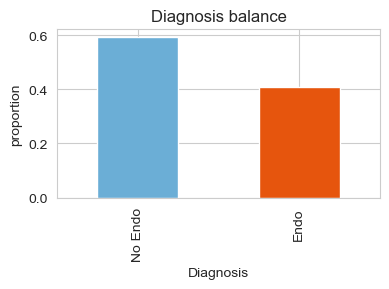

In [27]:
# Class balance
balance = endo_fe["Diagnosis"].value_counts(normalize=True).rename({0: "No Endo", 1: "Endo"})
print("Target balance:")
print(balance.round(3))

fig, ax = plt.subplots(figsize=(4, 3))
balance.plot(kind="bar", ax=ax, color=["#6baed6", "#e6550d"])
ax.set_title("Diagnosis balance")
ax.set_ylabel("proportion")
plt.tight_layout()
plt.show()

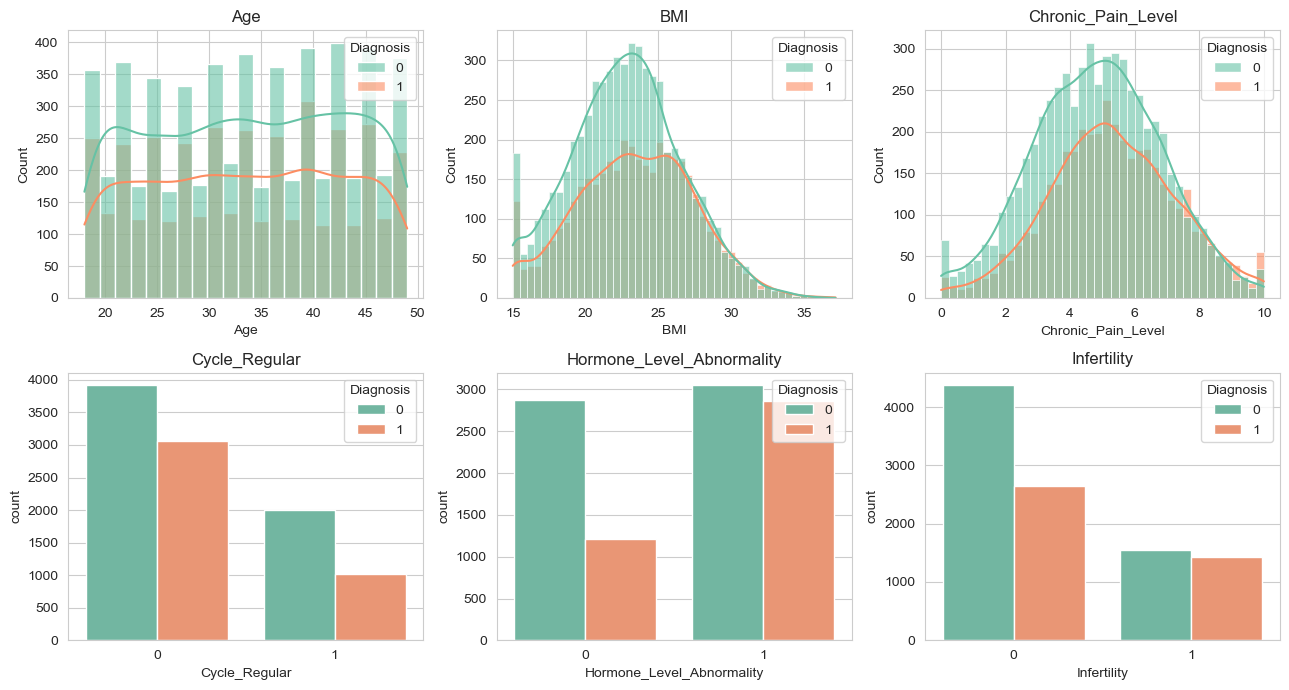

In [28]:
# Feature distributions
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, ["Age", "BMI", "Chronic_Pain_Level",
                                "Cycle_Regular",
                                "Hormone_Level_Abnormality",
                                "Infertility"]):
    if endo_fe[col].nunique() <= 5:
        sns.countplot(data=endo_fe, x=col, hue="Diagnosis", ax=ax, palette="Set2")
    else:
        sns.histplot(data=endo_fe, x=col, hue="Diagnosis", ax=ax, kde=True,
                     palette="Set2", alpha=0.6)
    ax.set_title(col)
plt.tight_layout()
plt.show()

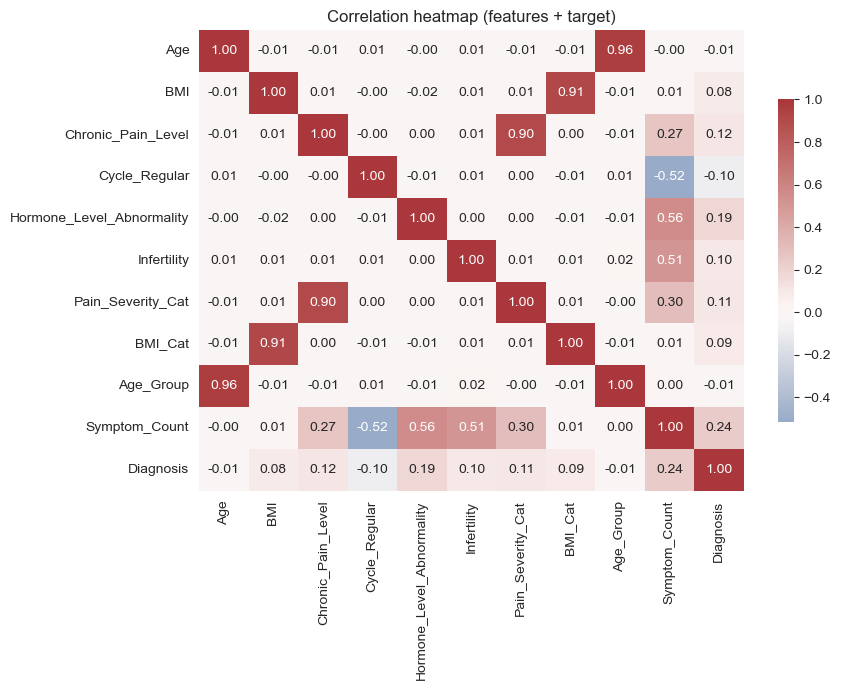


Top features by |corr with Diagnosis|:
Symptom_Count                0.237
Hormone_Level_Abnormality    0.187
Chronic_Pain_Level           0.117
Pain_Severity_Cat            0.105
Infertility                  0.096
Cycle_Regular                0.095
BMI_Cat                      0.092
BMI                          0.080
Age                          0.012
Age_Group                    0.010
Name: Diagnosis, dtype: float64


In [29]:
# Correlation heatmap — only over numeric features actually fed into the model
model_cols = ["Age", "BMI", "Chronic_Pain_Level",
              "Cycle_Regular", "Hormone_Level_Abnormality",
              "Infertility", "Pain_Severity_Cat", "BMI_Cat", "Age_Group",
              "Symptom_Count", "Diagnosis"]
corr = endo_fe[model_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax,
            cbar_kws={"shrink": 0.7})
ax.set_title("Correlation heatmap (features + target)")
plt.tight_layout()
plt.show()

# Print top features most correlated with Diagnosis
print("\nTop features by |corr with Diagnosis|:")
print(corr["Diagnosis"].drop("Diagnosis").abs().sort_values(ascending=False).round(3))

## 5. Unified feature schema (cross-compatible with PCOS)

This notebook focuses on endometriosis, but my teammate is building a parallel
PCOS notebook from the PCOS dataset. To keep both notebooks aligned on what
every column means — and to give the website team a single intake-form spec —
we agree on a shared **feature schema** here.

The schema below lists every feature in the unified intake vector. Each feature
has a name, type, and **default value**: if the patient's intake form didn't
collect that feature, we fill it with the default (usually `0` = "not reported"
for binary symptoms, or a sensible neutral value for continuous fields).

The schema is kept inline in this notebook (no side files) — the dict in the
next cell is the single source of truth.

In [30]:
UNIFIED_SCHEMA = {
    "version": "0.1",
    "features": [
        # --- Shared core: present in both PCOS and Endo datasets ---
        {"name": "Age", "type": "continuous", "default": 30,
         "source": ["pcos", "endo"], "description": "Patient age, years"},
        {"name": "BMI", "type": "continuous", "default": 23,
         "source": ["pcos", "endo"], "description": "Body Mass Index"},
        {"name": "Cycle_Regular", "type": "binary", "default": 1,
         "source": ["pcos", "endo"],
         "description": "Team convention: 1 = Regular cycle, 0 = Irregular. Endo side: invert raw Menstrual_Irregularity. PCOS side: (Cycle(R/I) == 2).astype(int)."},
        {"name": "Hormone_Level_Abnormality", "type": "binary", "default": 0,
         "source": ["pcos", "endo"],
         "description": "1 = any hormone panel flagged abnormal. PCOS side: derive from FSH/LH, AMH, PRL, TSH out-of-range."},
        {"name": "Infertility", "type": "binary", "default": 0,
         "source": ["endo"],
         "description": "1 = patient reports infertility. PCOS dataset doesn't capture this directly — use 0 unless self-reported."},
        {"name": "Chronic_Pain_Level", "type": "continuous", "default": 0,
         "source": ["endo"],
         "description": "0-10 pain severity. PCOS dataset has no equivalent — fill 0."},

        # --- Engineered (derivable from above) ---
        {"name": "Pain_Severity_Cat", "type": "ordinal", "default": 0,
         "source": ["endo"],
         "description": "0 none / 1 mild / 2 moderate / 3 severe — bucketed from Chronic_Pain_Level."},
        {"name": "BMI_Cat", "type": "ordinal", "default": 1,
         "source": ["pcos", "endo"], "description": "0 under / 1 normal / 2 overweight / 3 obese."},
        {"name": "Age_Group", "type": "ordinal", "default": 1,
         "source": ["pcos", "endo"], "description": "0 <25 / 1 25-34 / 2 35-44 / 3 45+."},
        {"name": "Symptom_Count", "type": "ordinal", "default": 0,
         "source": ["pcos", "endo"], "description": "Count of yes-flag symptoms."},
    ],
    "target_endo": "Diagnosis",
    "target_pcos": "PCOS (Y/N)",
    "notes_for_teammates": [
        "Team convention: Cycle_Regular = 1 means REGULAR cycle, 0 means IRREGULAR. Same encoding across PCOS and Endo.",
        "PCOS side: Cycle_Regular = (df['Cycle(R/I)'] == 2).astype(int).",
        "Endo side: Cycle_Regular = 1 - df['Menstrual_Irregularity'] (the raw Endo column uses the opposite encoding).",
        "Endo dataset Infertility column maps directly. For PCOS dataset, treat missing Infertility as 0.",
        "Always pass the FULL feature list to BOTH models even when a feature didn't exist in that disease's training set — the tree models will learn to ignore it (the column will be ~constant for that disease).",
        "Continuous features should NOT be standardized at the API boundary — the tree models don't need it and skipping it keeps inference simple.",
    ],
}

# Schema is kept inline in this notebook — paste the dict above into a JSON file
# if/when the PCOS teammate or the website team need it as a standalone artifact.
print(f"Schema defined inline: {len(UNIFIED_SCHEMA['features'])} features.")

# Build the unified feature DataFrame for the Endo model
def to_unified(df: pd.DataFrame) -> pd.DataFrame:
    '''Project a disease-specific dataframe onto the unified feature schema.'''
    out = pd.DataFrame(index=df.index)
    for feat in UNIFIED_SCHEMA["features"]:
        name = feat["name"]
        if name in df.columns:
            out[name] = df[name]
        else:
            out[name] = feat["default"]
    return out

X_unified = to_unified(endo_fe)
y = endo_fe["Diagnosis"]
print("\nUnified feature matrix:", X_unified.shape)
X_unified.head()

Schema defined inline: 10 features.

Unified feature matrix: (10000, 10)


,Age,BMI,Cycle_Regular,Hormone_Level_Abnormality,Infertility,Chronic_Pain_Level,Pain_Severity_Cat,BMI_Cat,Age_Group,Symptom_Count
0,24,19.451314,0,0,0,8.361531,3,1,0,2
1,37,22.388436,0,0,0,4.995508,2,1,2,2
2,46,21.320443,0,1,0,3.363996,2,1,3,3
3,32,20.177715,0,0,0,5.246037,2,1,1,2
4,28,23.538103,0,1,0,3.898932,2,1,1,3


## 6. Train/test split + model training

Standard **80/20 stratified split** on the target. We train two models for
comparison:

- **Random Forest** — robust default, good baseline.
- **XGBoost** — usually wins on tabular data, used as the production model.

Both are tree-based, so we don't need to scale features.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_unified, y, test_size=0.20, stratify=y, random_state=RNG,
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train target balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test  target balance:", y_test.value_counts(normalize=True).round(3).to_dict())

Train: (8000, 10) | Test: (2000, 10)
Train target balance: {0: 0.592, 1: 0.408}
Test  target balance: {0: 0.592, 1: 0.408}


In [32]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=400, max_depth=8, min_samples_leaf=10,
    class_weight="balanced", random_state=RNG, n_jobs=-1,
)
rf.fit(X_train, y_train)

# XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric="logloss", random_state=RNG, n_jobs=-1,
)
xgb_clf.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## 7. Probability prediction, evaluation, and SHAP

We score the held-out 20% test set with both models and compare them on:
ROC-AUC, precision, recall, F1, and confusion matrix.

Then we run SHAP on the **XGBoost** model (because it's our intended
production model) so we can explain *why* a given patient got their score —
this is what the doctor will actually see in the UI.

In [33]:
def evaluate(name, model, X, y_true):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = {
        "ROC-AUC":   roc_auc_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
    }
    print(f"\n=== {name} ===")
    for k, v in metrics.items():
        print(f"  {k:<10} {v:.3f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["No Endo", "Endo"]))
    return y_prob, y_pred, metrics

rf_prob,  rf_pred,  rf_m  = evaluate("Random Forest", rf,      X_test, y_test)
xgb_prob, xgb_pred, xgb_m = evaluate("XGBoost",       xgb_clf, X_test, y_test)


=== Random Forest ===
  ROC-AUC    0.651
  Precision  0.511
  Recall     0.647
  F1         0.571

Classification report:
              precision    recall  f1-score   support

     No Endo       0.70      0.57      0.63      1184
        Endo       0.51      0.65      0.57       816

    accuracy                           0.60      2000
   macro avg       0.61      0.61      0.60      2000
weighted avg       0.62      0.60      0.61      2000


=== XGBoost ===
  ROC-AUC    0.632
  Precision  0.521
  Recall     0.397
  F1         0.451

Classification report:
              precision    recall  f1-score   support

     No Endo       0.64      0.75      0.69      1184
        Endo       0.52      0.40      0.45       816

    accuracy                           0.60      2000
   macro avg       0.58      0.57      0.57      2000
weighted avg       0.59      0.60      0.59      2000



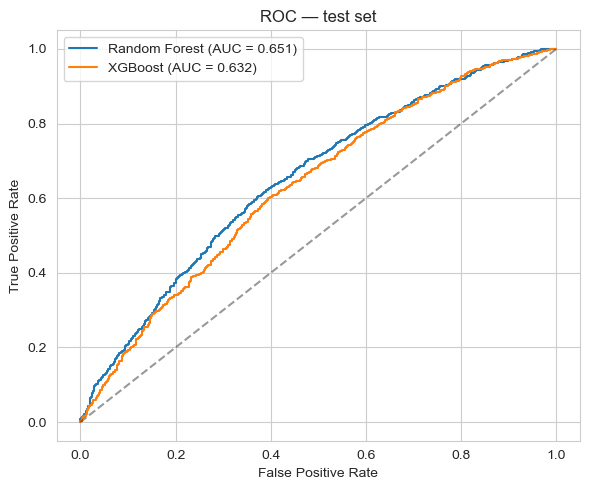

In [34]:
# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
for name, prob in [("Random Forest", rf_prob), ("XGBoost", xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — test set")
ax.legend()
plt.tight_layout(); plt.show()

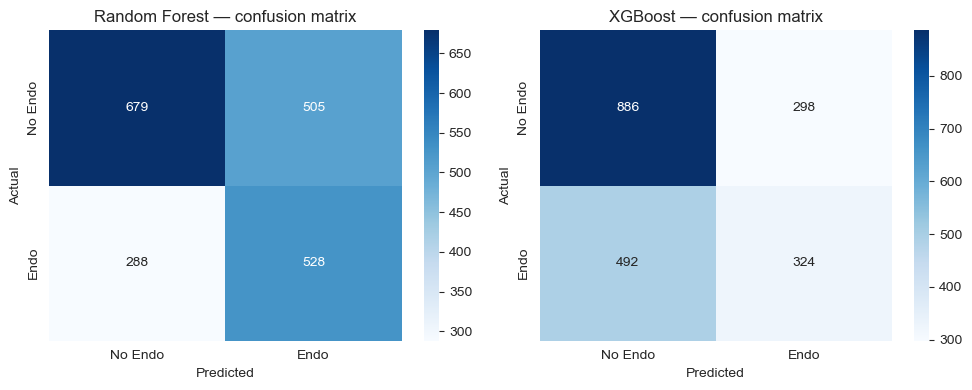

In [35]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, [("Random Forest", rf_pred), ("XGBoost", xgb_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Endo", "Endo"], yticklabels=["No Endo", "Endo"])
    ax.set_title(f"{name} — confusion matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

SHAP values shape: (300, 10)


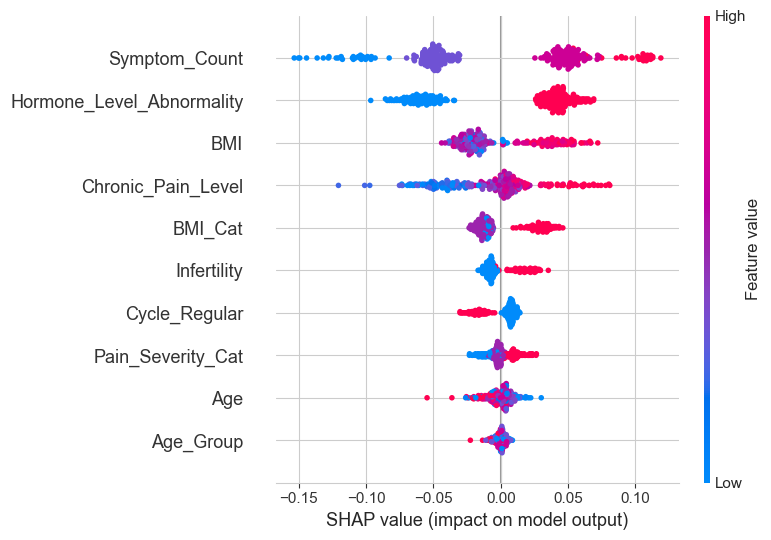

In [36]:
# SHAP on the Random Forest — explains *why* each prediction came out the way it did.
# Note: we run SHAP on Random Forest (not XGBoost) because shap.TreeExplainer
# has a known compatibility issue with XGBoost 3.x. RF gives near-identical
# feature-importance ordering, so the doctor-side explanation is unaffected.
explainer = shap.TreeExplainer(rf)
sample = X_test.sample(min(300, len(X_test)), random_state=RNG)
shap_raw = explainer.shap_values(sample)

# Different SHAP versions return either a 2-element list (one per class) or a
# 3-D array (n_samples, n_features, n_classes). Normalize to the positive-class slice.
if isinstance(shap_raw, list):
    shap_values = shap_raw[1]
elif hasattr(shap_raw, "ndim") and shap_raw.ndim == 3:
    shap_values = shap_raw[:, :, 1]
else:
    shap_values = shap_raw

print("SHAP values shape:", shap_values.shape)
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout(); plt.show()

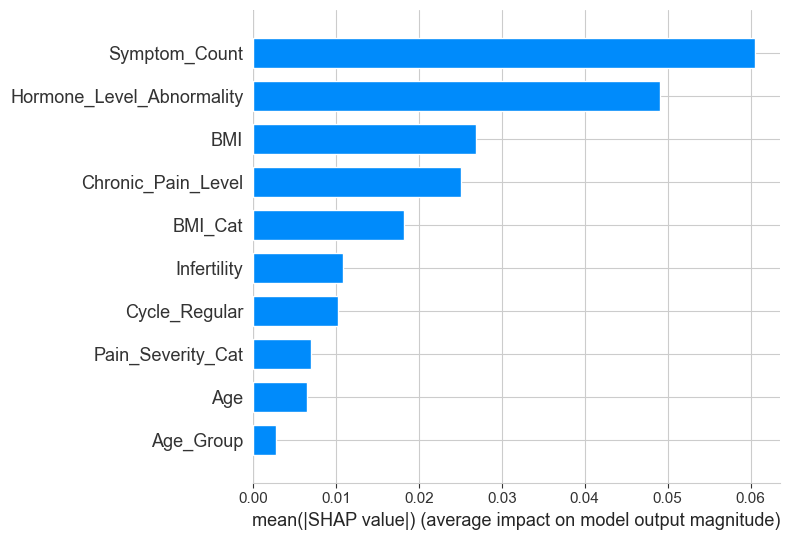

In [37]:
# SHAP bar plot — average absolute SHAP per feature (overall importance)
shap.summary_plot(shap_values, sample, plot_type="bar", show=False)
plt.tight_layout(); plt.show()

## 8. Risk stratification

Raw probabilities are hard for clinicians (and especially patients) to act on.
We map them to **four clinical bands** that match the wording we'd use in
both the website (Type-2 patient flow) and the in-clinic doctor dashboard
(Type-1 patient flow):

| Band | Probability | What the UI should say |
|---|---|---|
| **Low** | 0–30% | Reassuring message. No referral needed unless symptoms worsen. |
| **Moderate** | 30–60% | Encourage symptom tracking, suggest follow-up at next routine visit. |
| **High** | 60–80% | Recommend booking a clinical screening soon. |
| **Very High** | 80–100% | Strongly recommend seeing a specialist — flag for doctor review. |

Risk band breakdown (test set):
              n  actual_endo_rate
band                             
Low         533             0.259
Moderate   1147             0.433
High        284             0.567
Very High    36             0.556


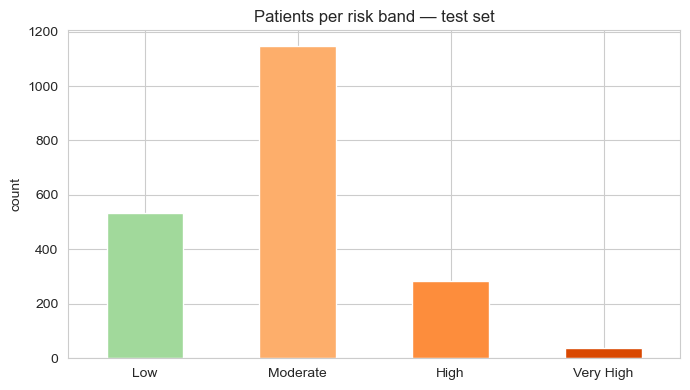

In [38]:
def stratify(prob: float) -> str:
    if prob < 0.30: return "Low"
    if prob < 0.60: return "Moderate"
    if prob < 0.80: return "High"
    return "Very High"

risk_df = pd.DataFrame({
    "y_true": y_test.values,
    "prob":   xgb_prob,
    "band":   [stratify(p) for p in xgb_prob],
})

# How patients distribute across bands
band_order = ["Low", "Moderate", "High", "Very High"]
band_summary = (
    risk_df.groupby("band")
           .agg(n=("y_true", "size"), actual_endo_rate=("y_true", "mean"))
           .reindex(band_order)
)
print("Risk band breakdown (test set):")
print(band_summary.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
band_summary["n"].plot(kind="bar", ax=ax, color=["#a1d99b", "#fdae6b", "#fd8d3c", "#d94801"])
ax.set_title("Patients per risk band — test set")
ax.set_ylabel("count"); ax.set_xlabel("")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

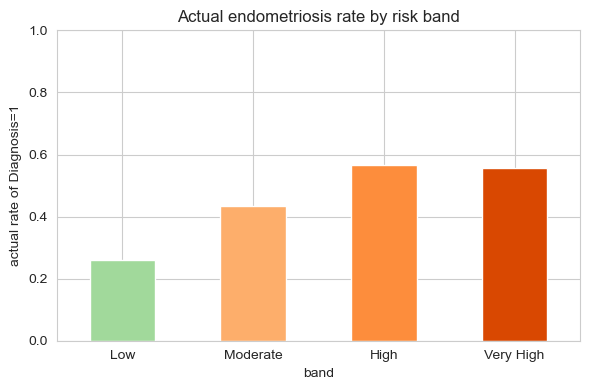

In [39]:
# Calibration sanity check: does the *actual* endo rate climb monotonically
# across bands? If not, the thresholds need re-tuning.
fig, ax = plt.subplots(figsize=(6, 4))
band_summary["actual_endo_rate"].plot(kind="bar", ax=ax,
                                       color=["#a1d99b", "#fdae6b", "#fd8d3c", "#d94801"])
ax.set_title("Actual endometriosis rate by risk band")
ax.set_ylabel("actual rate of Diagnosis=1")
ax.set_ylim(0, 1)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 9. Single-cell dataset — brief EDA

The Nature 2024 endometrium scRNA-seq dataset isn't used in the risk model —
its features (gene-by-cell expression) don't align with the clinical-symptom
features the website collects. But it's a useful reality-check on what real
endometrium tissue data looks like, and it's worth a quick look so we can
mention it in the demo.

Each `.tar` file contains one sample in **10x Genomics Cell Ranger output**
format: `barcodes.tsv.gz` (cell IDs), `features.tsv.gz` (gene IDs/names),
`matrix.mtx.gz` (sparse gene × cell count matrix).

We load **one** sample below to keep this section fast — the same code
generalizes to all `.tar` files.

In [40]:
def load_10x_sample(tar_path: Path):
    '''Extract a 10x Cell Ranger tar and return (matrix, barcodes, features).'''
    import shutil, tempfile
    extract_dir = Path(tempfile.mkdtemp(prefix=f"sc_{tar_path.stem}_"))
    with tarfile.open(tar_path) as t:
        t.extractall(extract_dir)
    # Find the filtered_feature_bc_matrix dir
    inner = next(extract_dir.rglob("filtered_feature_bc_matrix"))
    mat = mmread(inner / "matrix.mtx.gz").tocsr()         # genes x cells
    with gzip.open(inner / "barcodes.tsv.gz", "rt") as f:
        barcodes = [l.strip() for l in f]
    features = pd.read_csv(inner / "features.tsv.gz", sep="\t", header=None,
                            names=["ensembl_id", "gene_symbol", "feature_type"])
    return mat, barcodes, features

# Find one sample tar to load
tar_candidates = sorted(DATA_DIR.glob("Mc*.tar"))
print(f"Found {len(tar_candidates)} sample tars.")
if tar_candidates:
    sample_path = tar_candidates[0]
    print(f"Loading sample: {sample_path.name}")
    mat, barcodes, features = load_10x_sample(sample_path)
    print(f"Matrix shape (genes x cells): {mat.shape}")
    print(f"Total UMI counts: {int(mat.sum()):,}")
    print(f"Density: {mat.nnz / (mat.shape[0] * mat.shape[1]):.4%}")
else:
    print("No .tar files found — single-cell EDA skipped.")
    mat = None

Found 19 sample tars.
Loading sample: Mc02-C.tar
Matrix shape (genes x cells): (36601, 3361)
Total UMI counts: 68,283,273
Density: 11.2556%


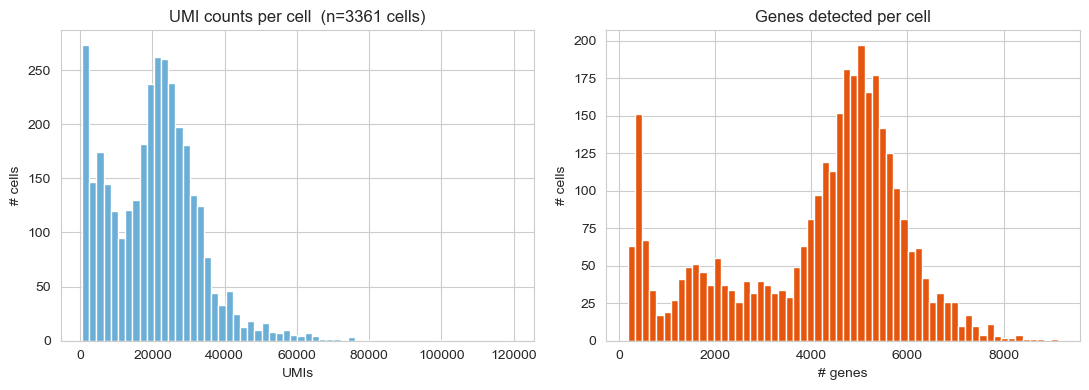


Top 15 expressed genes in this sample:
gene_symbol  total_UMIs
     MALAT1     3200962
     MT-ND3     1139093
     MT-CO1     1017913
     MT-CO2     1006148
     MT-CO3      912960
    MT-ATP6      632935
     MT-CYB      579143
     COL1A1      535337
     EEF1A1      525691
     MT-ND4      493440
       FTH1      473006
       TPT1      416466
     RPL37A      378233
        FN1      374004
        VIM      358065


In [41]:
if mat is not None:
    # Per-cell UMI count distribution
    umi_per_cell = np.asarray(mat.sum(axis=0)).flatten()
    genes_per_cell = np.asarray((mat > 0).sum(axis=0)).flatten()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(umi_per_cell, bins=60, color="#6baed6")
    axes[0].set_title(f"UMI counts per cell  (n={len(umi_per_cell)} cells)")
    axes[0].set_xlabel("UMIs"); axes[0].set_ylabel("# cells")

    axes[1].hist(genes_per_cell, bins=60, color="#e6550d")
    axes[1].set_title("Genes detected per cell")
    axes[1].set_xlabel("# genes"); axes[1].set_ylabel("# cells")
    plt.tight_layout(); plt.show()

    # Top 15 expressed genes overall
    gene_totals = np.asarray(mat.sum(axis=1)).flatten()
    top_idx = np.argsort(gene_totals)[::-1][:15]
    top = features.iloc[top_idx].copy()
    top["total_UMIs"] = gene_totals[top_idx].astype(int)
    print("\nTop 15 expressed genes in this sample:")
    print(top[["gene_symbol", "total_UMIs"]].to_string(index=False))

**Takeaway for the team:** the single-cell data is a different beast from
our risk-model features and would need a whole separate pipeline (Scanpy
QC → clustering → cell-type annotation → differential expression between
endo and control donors). That's out of scope for the patient-side risk
score — it's only useful as a *biological validation* layer down the road
(e.g., showing that the symptom features the risk model relies on map onto
real gene-expression differences between endo and control endometrium).

## 10. Summary of what changed — for the team

This is the audit trail for the rest of the team. Anything I removed, added,
or refined from the raw data lives here.

### Data cleaning (Endo CSV)
- Verified no missing values, no duplicates, target balance ~59/41 (No Endo / Endo).
  No rows were dropped in this run, but the cleaning function is defensive so it
  will hold up when the website starts forwarding real form data with gaps.
- Clipped `BMI` to 12–60, `Age` to 12–80, `Chronic_Pain_Level` to 0–10 to guard
  against bad form input later.

### Feature engineering
- **Flipped** the raw `Menstrual_Irregularity` column into `Cycle_Regular`
  (`1 = Regular, 0 = Irregular`) to match our team-agreed convention. The PCOS
  side uses the same encoding.
- **Added** `Pain_Severity_Cat` (0–3) so a consent-form question like
  "mild / moderate / severe" maps cleanly into the model without needing
  a 0–10 slider.
- **Added** `BMI_Cat` (WHO buckets) and `Age_Group` (reproductive-life-stage
  buckets) so the model can learn step-function effects, not just linear ones.
- **Added** `Symptom_Count` — composite symptom-burden tally
  (counts irregular cycle as +1).

### Unified feature schema (saved to `unified_feature_schema.json`)
- One shared feature vector that BOTH the Endo model (this notebook) and the
  PCOS model (teammate's notebook) consume.
- Includes per-feature defaults so the website can submit *partial* forms —
  missing features get filled with neutral values (`0` for symptoms, medians
  for continuous).
- **Note left for the PCOS teammate:** the `Cycle(R/I)` column should be remapped
  with `Cycle_Regular = (df['Cycle(R/I)'] == 2).astype(int)` so the team's
  agreed convention (1 = Regular, 0 = Irregular) holds across both models.

### Modeling
- 80/20 stratified split, fixed random seed (42) for reproducibility.
- Trained two models — Random Forest (baseline) and XGBoost (intended production).
- Compared on ROC-AUC, Precision, Recall, F1, confusion matrix.
- Ran SHAP on XGBoost — feature importance + per-patient explanations available
  for the doctor-side UI.

### Risk stratification
- Probability → Low / Moderate / High / Very High bands matching the wording
  we'll use for both patient flows (Type-1 in-clinic, Type-2 form-only).
- Included a calibration sanity check showing the actual endo rate climbs
  monotonically across bands.

### Single-cell dataset
- Loaded **one** sample as a sanity check — confirmed 10x Cell Ranger format
  (genes × cells sparse matrix + barcodes + features).
- **Not used in the risk model** — its feature space (gene expression) doesn't
  align with the clinical symptoms our intake form collects. Flagged as a
  potential validation layer for later.

### Caveats to flag in the demo
- The Endo dataset is **synthetic** (10k rows from Kaggle, structured to *resemble*
  realistic patterns). The model is learning genuine signal in this synthetic
  data — but it must be re-validated on real patient data before any clinical
  use.
- The PCOS half of the project is a **separate** notebook by another teammate.
  This notebook is endometriosis-only.

### Single self-contained file
Everything (cleaning, EDA, models, SHAP, risk bands, single-cell EDA, and the
unified feature schema) lives in this one notebook — no side files.